# Cook County Property Tax Equity Analysis
## Notebook 10 — k=2 Visuals & Refined Transition Analysis

1. k=2 clustering map and profiles
2. Transition burden analysis (short-term cost vs long-term benefit)
3. Policy recommendation framing

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q contextily geopandas

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = "/content/drive/MyDrive/cook-county-tax-equity"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
FIGURES_DIR = f"{PROJECT_DIR}/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)
RANDOM_STATE = 42

In [3]:
# Load data
tracts = pd.read_parquet(f"{PROCESSED_DIR}/tracts_with_clusters.parquet")
res_lvt = pd.read_parquet(f"{PROCESSED_DIR}/residential_with_lvt_dedup.parquet")
print(f"Tracts: {len(tracts):,} | Parcels: {len(res_lvt):,}")

Tracts: 1,270 | Parcels: 1,605,925


---
## Part 1: k=2 Clustering

In [4]:
# Fit k=2 GMM
cluster_features = [
    "median_ratio", "median_land_ratio", "median_tax_change_pct",
    "pct_lvt_benefit", "median_household_income", "pct_black",
    "pct_hispanic", "pct_owner_occupied", "median_predicted_value",
]

X_clust = tracts[cluster_features].dropna()
X_s = StandardScaler().fit_transform(X_clust)
X_pca = PCA(n_components=5, random_state=RANDOM_STATE).fit_transform(X_s)

gmm2 = GaussianMixture(n_components=2, covariance_type="full", n_init=10, random_state=RANDOM_STATE)
labels2 = gmm2.fit_predict(X_pca)

tracts_k2 = tracts.loc[X_clust.index].copy()
tracts_k2["cluster"] = labels2

# Ensure cluster 1 = Black/disadvantaged (swap if needed)
if tracts_k2[tracts_k2["cluster"]==0]["pct_black"].median() > tracts_k2[tracts_k2["cluster"]==1]["pct_black"].median():
    tracts_k2["cluster"] = 1 - tracts_k2["cluster"]

names = {
    0: "Predominantly White/Hispanic",
    1: "Predominantly Black"
}
tracts_k2["cluster_name"] = tracts_k2["cluster"].map(names)

# Profile
print("k=2 Cluster Profiles:")
print("=" * 70)
for c in [0, 1]:
    s = tracts_k2[tracts_k2["cluster"] == c]
    print(f"\n  {names[c]} ({len(s)} tracts):")
    print(f"    Median income:       ${s['median_household_income'].median():>10,.0f}")
    print(f"    % Black:             {s['pct_black'].median():>10.1f}%")
    print(f"    % Hispanic:          {s['pct_hispanic'].median():>10.1f}%")
    print(f"    Assessment ratio:    {s['median_ratio'].median():>10.3f}")
    print(f"    Land ratio:          {s['median_land_ratio'].median():>10.3f}")
    print(f"    % LVT benefit:       {s['pct_lvt_benefit'].median():>10.1f}%")
    print(f"    Med tax change:      {s['median_tax_change_pct'].median():>+10.1f}%")
    print(f"    Median home value:   ${s['median_predicted_value'].median():>10,.0f}")

k=2 Cluster Profiles:

  Predominantly White/Hispanic (940 tracts):
    Median income:       $    88,160
    % Black:                    3.8%
    % Hispanic:                19.8%
    Assessment ratio:         0.800
    Land ratio:               0.203
    % LVT benefit:             62.5%
    Med tax change:           -10.8%
    Median home value:   $   423,914

  Predominantly Black (330 tracts):
    Median income:       $    47,246
    % Black:                   85.8%
    % Hispanic:                 5.4%
    Assessment ratio:         0.634
    Land ratio:               0.269
    % LVT benefit:             35.0%
    Med tax change:           +19.9%
    Median home value:   $   196,890


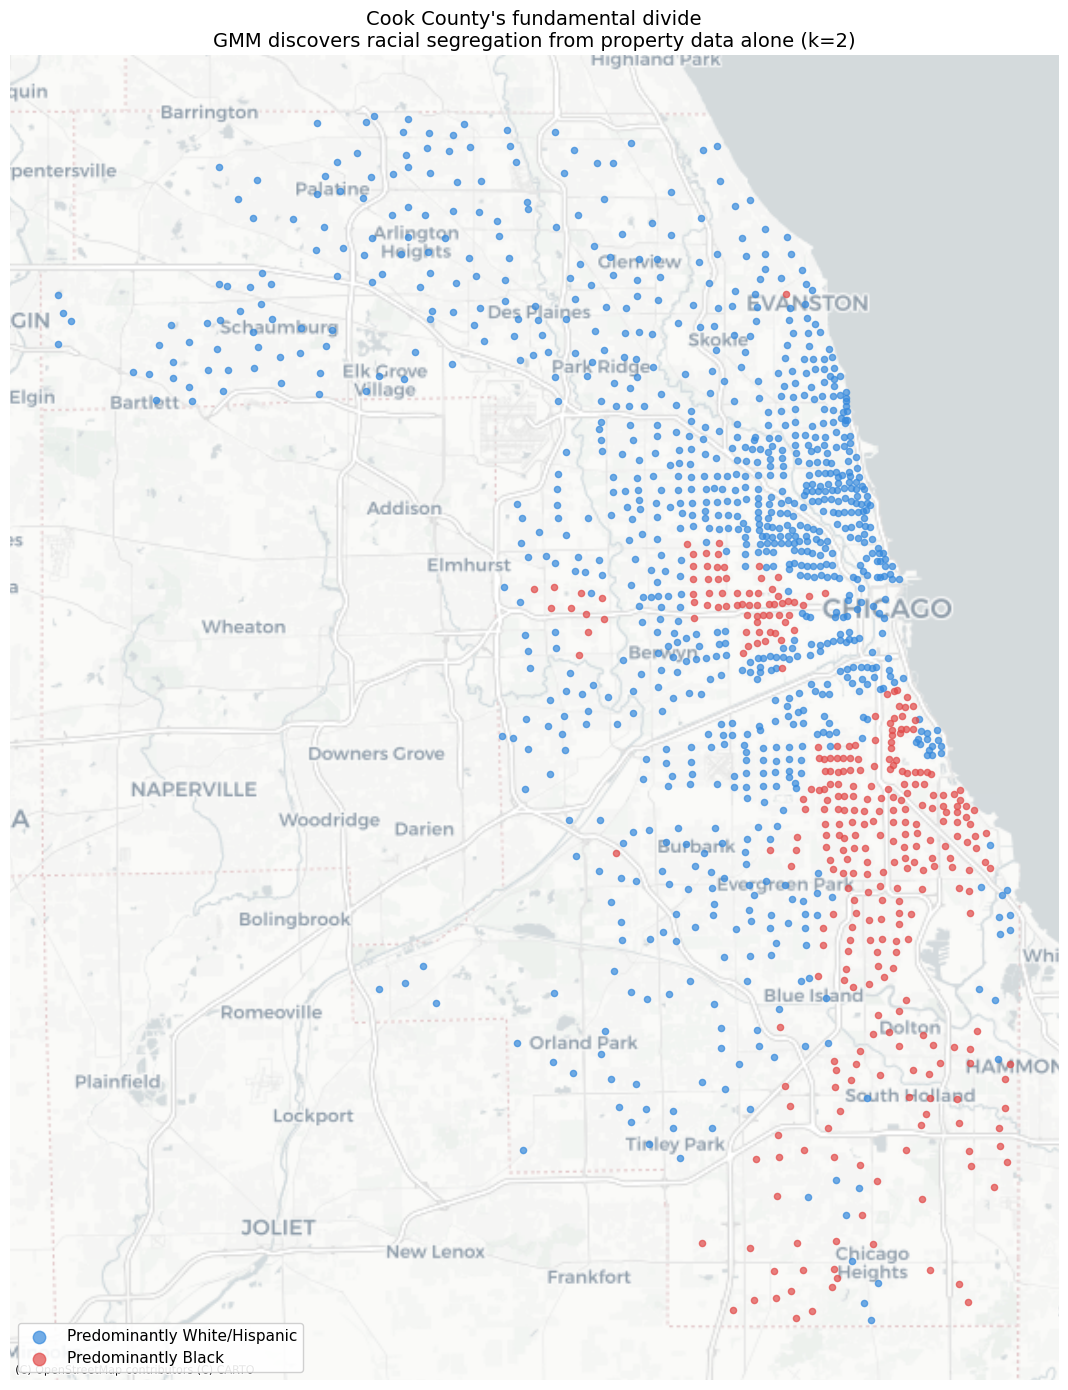

In [5]:
# === MAP: k=2 on Chicago basemap ===
tract_coords = res_lvt.groupby("census_tract_geoid").agg(
    lat=("lat", "median"), lon=("lon", "median")
).reset_index()

map_k2 = tracts_k2[["census_tract_geoid", "cluster", "cluster_name"]].merge(
    tract_coords, on="census_tract_geoid", how="inner"
).dropna(subset=["lat", "lon"])
map_k2 = map_k2[(map_k2["lat"] > 41.4) & (map_k2["lat"] < 42.2) &
                 (map_k2["lon"] > -88.3) & (map_k2["lon"] < -87.4)]

geometry = [Point(xy) for xy in zip(map_k2["lon"], map_k2["lat"])]
gdf = gpd.GeoDataFrame(map_k2, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 14))
colors = {0: "#378ADD", 1: "#E24B4A"}
for c in [0, 1]:
    sub = gdf[gdf["cluster"] == c]
    sub.plot(ax=ax, markersize=20, color=colors[c], alpha=0.7, label=names[c])

try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass

ax.set_title("Cook County's fundamental divide\n"
             "GMM discovers racial segregation from property data alone (k=2)",
             fontsize=14)
ax.legend(loc="lower left", fontsize=11, framealpha=0.9, markerscale=2)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/k2_map.png", dpi=200, bbox_inches="tight")
plt.show()

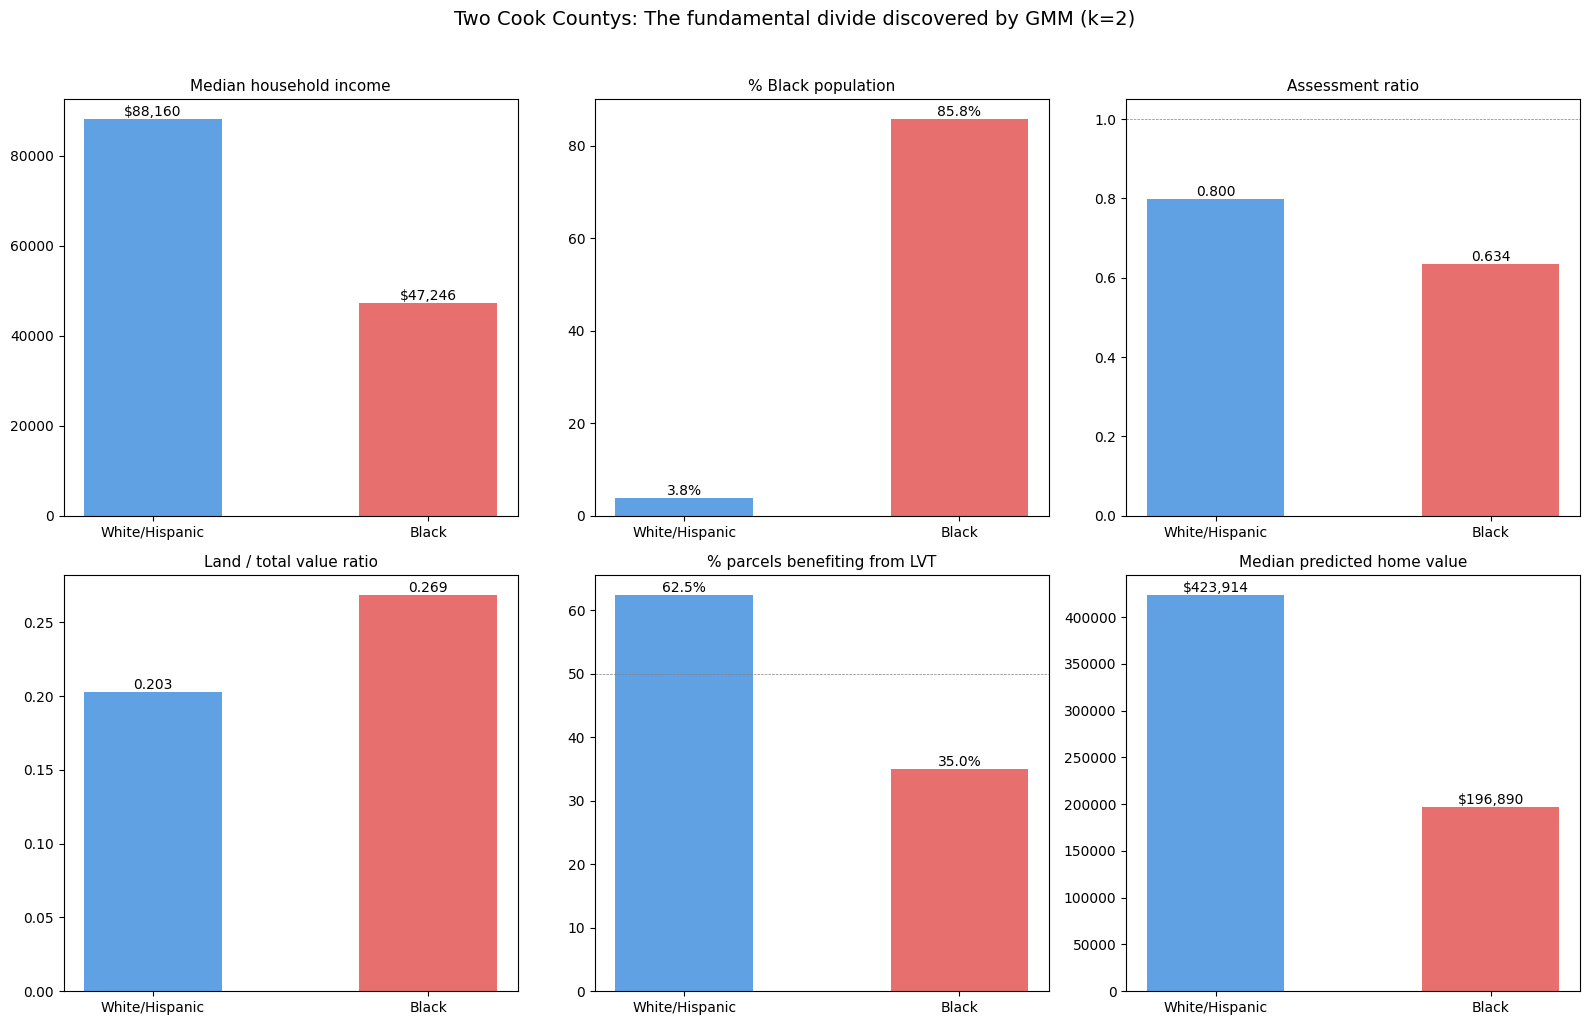

In [6]:
# === BAR CHART: k=2 profiles ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics = [
    ("median_household_income", "Median household income", "${:,.0f}"),
    ("pct_black", "% Black population", "{:.1f}%"),
    ("median_ratio", "Assessment ratio", "{:.3f}"),
    ("median_land_ratio", "Land / total value ratio", "{:.3f}"),
    ("pct_lvt_benefit", "% parcels benefiting from LVT", "{:.1f}%"),
    ("median_predicted_value", "Median predicted home value", "${:,.0f}"),
]

bar_colors = ["#378ADD", "#E24B4A"]
bar_labels = ["White/Hispanic", "Black"]

for ax, (col, title, fmt) in zip(axes, metrics):
    vals = [tracts_k2[tracts_k2["cluster"]==c][col].median() for c in [0, 1]]
    bars = ax.bar(bar_labels, vals, color=bar_colors, alpha=0.8, width=0.5)
    ax.set_title(title, fontsize=11)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(v), ha="center", va="bottom", fontsize=10)
    # Add reference lines for key metrics
    if col == "median_ratio":
        ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
    if col == "pct_lvt_benefit":
        ax.axhline(50, color="gray", linestyle="--", linewidth=0.5)

plt.suptitle("Two Cook Countys: The fundamental divide discovered by GMM (k=2)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/k2_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

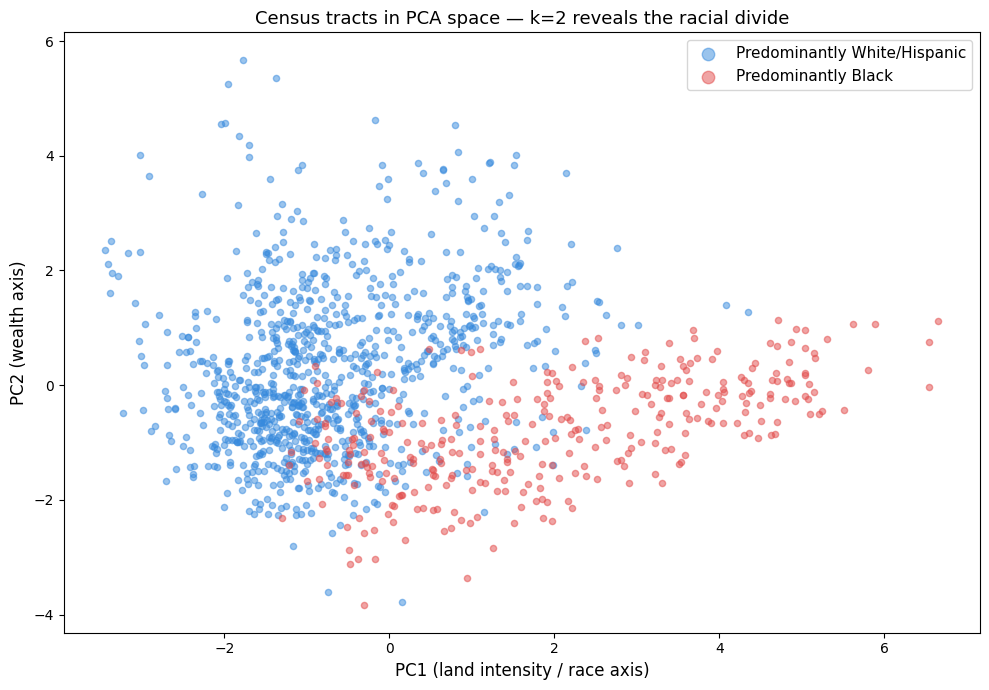

In [7]:
# === PCA scatter colored by k=2 ===
fig, ax = plt.subplots(figsize=(10, 7))
for c in [0, 1]:
    mask = tracts_k2.loc[X_clust.index, "cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], alpha=0.5, s=20, label=names[c])

ax.set_xlabel("PC1 (land intensity / race axis)", fontsize=12)
ax.set_ylabel("PC2 (wealth axis)", fontsize=12)
ax.set_title("Census tracts in PCA space — k=2 reveals the racial divide", fontsize=13)
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/k2_pca.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 2: Transition Burden Analysis

LVT's long-term effect is to incentivize investment in improvements.
But the short-term effect is a tax increase on land-heavy properties.

Key question: How much investment would redlined neighborhoods need
to *break even* under LVT? And what does a phased transition look like?

In [8]:
# Define majority groups in parcel data
res_lvt["majority_group"] = np.where(
    res_lvt["pct_black"] > 50, "Majority Black",
    np.where(res_lvt["pct_hispanic"] > 50, "Majority Hispanic",
    np.where(res_lvt["pct_white"] > 50, "Majority White", "Mixed")))

# For parcels that lose under LVT: how much additional improvement value
# would they need to break even?
losers = res_lvt[res_lvt["tax_change"] > 0].copy()

# Under current system: tax ∝ (land_AV + bldg_AV)
# Under LVT: tax ∝ land_AV × multiplier
# Break even: land_AV × multiplier = (land_AV + bldg_AV + X) where X = needed improvement
# So X = land_AV × (multiplier - 1) - bldg_AV
# But since we're revenue-neutral, it's simpler:
# The parcel breaks even when its land_ratio drops to the county median

county_median_land_ratio = res_lvt["land_ratio"].median()
print(f"County median land ratio: {county_median_land_ratio:.3f}")
print(f"A parcel breaks even under LVT when its land ratio ≤ ~{county_median_land_ratio:.3f}")

# For losers: how far are they from break-even?
losers["gap_to_breakeven"] = losers["land_ratio"] - county_median_land_ratio
losers["needed_improvement_pct"] = (losers["gap_to_breakeven"] / losers["land_ratio"] * 100)

print(f"\nParcels that LOSE under LVT: {len(losers):,}")
print(f"\nHow far from break-even? (land ratio gap):")
for group in ["Majority Black", "Majority Hispanic", "Majority White", "Mixed"]:
    sub = losers[losers["majority_group"] == group]
    if len(sub) > 0:
        gap = sub["gap_to_breakeven"].median()
        needed = sub["needed_improvement_pct"].median()
        curr_bldg = sub["market_value_bldg"].median()
        # Approximate dollar investment needed
        dollar_needed = curr_bldg * (needed / 100) if needed > 0 else 0
        print(f"  {group:22s}: gap={gap:.3f}, would need ~{needed:.0f}% more improvement value (~${dollar_needed:,.0f})")

County median land ratio: 0.197
A parcel breaks even under LVT when its land ratio ≤ ~0.197

Parcels that LOSE under LVT: 634,352

How far from break-even? (land ratio gap):
  Majority Black        : gap=0.165, would need ~46% more improvement value (~$26,593)
  Majority Hispanic     : gap=0.112, would need ~36% more improvement value (~$47,169)
  Majority White        : gap=0.097, would need ~33% more improvement value (~$77,388)
  Mixed                 : gap=0.113, would need ~36% more improvement value (~$57,649)


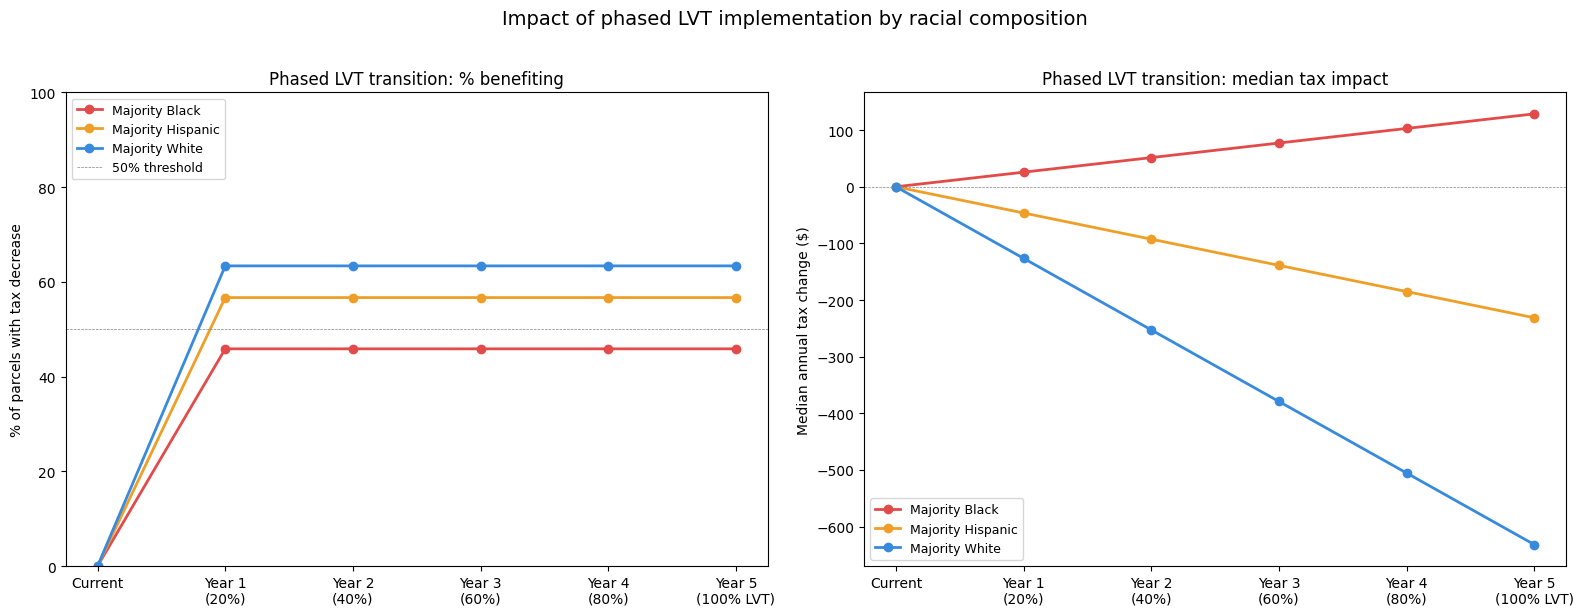

In [9]:
# === Phased transition simulation ===
# What if LVT was phased in over 5 years (20% per year)?
# Year 1: 80% current + 20% LVT
# Year 5: 0% current + 100% LVT

phases = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # 0 = current, 1 = full LVT
phase_labels = ["Current", "Year 1\n(20%)", "Year 2\n(40%)", "Year 3\n(60%)",
                "Year 4\n(80%)", "Year 5\n(100% LVT)"]

results_by_group = {}
for group in ["Majority Black", "Majority Hispanic", "Majority White"]:
    sub = res_lvt[res_lvt["majority_group"] == group]
    pct_benefit = []
    median_change = []
    for phase in phases:
        blended_tax = (1 - phase) * sub["current_tax_est"] + phase * sub["lvt_tax_est"]
        change = blended_tax - sub["current_tax_est"]
        pct_benefit.append((change < 0).mean() * 100)
        median_change.append(change.median())
    results_by_group[group] = {"pct_benefit": pct_benefit, "median_change": median_change}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_group = {"Majority Black": "#E24B4A", "Majority Hispanic": "#EF9F27",
                "Majority White": "#378ADD"}

# % benefiting at each phase
ax = axes[0]
for group, data in results_by_group.items():
    ax.plot(range(len(phases)), data["pct_benefit"], 'o-',
            color=colors_group[group], label=group, linewidth=2, markersize=6)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.5, label="50% threshold")
ax.set_xticks(range(len(phases)))
ax.set_xticklabels(phase_labels)
ax.set_ylabel("% of parcels with tax decrease")
ax.set_title("Phased LVT transition: % benefiting")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, 100)

# Median dollar change at each phase
ax = axes[1]
for group, data in results_by_group.items():
    ax.plot(range(len(phases)), data["median_change"], 'o-',
            color=colors_group[group], label=group, linewidth=2, markersize=6)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xticks(range(len(phases)))
ax.set_xticklabels(phase_labels)
ax.set_ylabel("Median annual tax change ($)")
ax.set_title("Phased LVT transition: median tax impact")
ax.legend(loc="lower left", fontsize=9)

plt.suptitle("Impact of phased LVT implementation by racial composition", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/phased_transition.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# === What % phase-in keeps ALL groups above 40% benefit? ===
print("At what phase does each group cross 50% benefiting?")
print("=" * 55)
for group, data in results_by_group.items():
    crossed = None
    for i, pct in enumerate(data["pct_benefit"]):
        if pct >= 50 and i > 0:
            crossed = i
            break
    if crossed:
        print(f"  {group:22s}: crosses 50% at {phase_labels[crossed].strip()} ({phases[crossed]*100:.0f}% LVT)")
    else:
        print(f"  {group:22s}: never reaches 50% — needs complementary policy")

At what phase does each group cross 50% benefiting?
  Majority Black        : never reaches 50% — needs complementary policy
  Majority Hispanic     : crosses 50% at Year 1
(20%) (20% LVT)
  Majority White        : crosses 50% at Year 1
(20%) (20% LVT)


---
## Part 3: Homestead Exemption Simulation

What if LVT included a homestead exemption that shields the first
$X of land value from taxation? This directly protects low-value
homeowners in historically redlined areas.

In [11]:
# Simulate homestead exemptions at different levels
exemption_levels = [0, 10000, 20000, 30000, 50000]

STATE_EQUALIZER = 2.9
COMPOSITE_RATE = 0.07
LVT_MULT = 4.45

print("Effect of homestead exemptions on LVT equity:")
print("=" * 80)
print(f"{'Exemption':>12s} {'% Black benefit':>16s} {'% Hisp benefit':>16s} {'% White benefit':>16s}")
print("-" * 80)

exemption_results = []

for exempt_val in exemption_levels:
    # Exempt the first $exempt_val of land AV from LVT
    taxable_land = (res_lvt["final_land"] - exempt_val).clip(lower=0)

    # Recompute revenue-neutral rate with exemption
    total_current_rev = (res_lvt["final_tot"] * STATE_EQUALIZER * COMPOSITE_RATE).sum()
    total_taxable_land = taxable_land.sum()

    if total_taxable_land > 0:
        new_mult = total_current_rev / (total_taxable_land * STATE_EQUALIZER * COMPOSITE_RATE)
    else:
        continue

    lvt_with_exempt = taxable_land * STATE_EQUALIZER * COMPOSITE_RATE * new_mult
    change = lvt_with_exempt - res_lvt["current_tax_est"]
    benefits = change < 0

    row = {"exemption": exempt_val}
    for group in ["Majority Black", "Majority Hispanic", "Majority White"]:
        mask = res_lvt["majority_group"] == group
        pct = benefits[mask].mean() * 100
        row[group] = pct

    exemption_results.append(row)
    print(f"  ${exempt_val:>10,}   {row['Majority Black']:>14.1f}%   {row['Majority Hispanic']:>14.1f}%   {row['Majority White']:>14.1f}%")

# Find the exemption level where Black communities reach 50%+
print("\n→ The exemption level needed for majority-Black neighborhoods to reach 50% benefit")
print("  tells policymakers exactly what complementary policy is required.")

Effect of homestead exemptions on LVT equity:
   Exemption  % Black benefit   % Hisp benefit  % White benefit
--------------------------------------------------------------------------------
  $         0             39.3%             48.6%             57.0%
  $    10,000             98.2%             95.7%             83.8%
  $    20,000             99.7%             99.8%             94.1%
  $    30,000             99.9%            100.0%             96.8%
  $    50,000            100.0%            100.0%             99.3%

→ The exemption level needed for majority-Black neighborhoods to reach 50% benefit
  tells policymakers exactly what complementary policy is required.


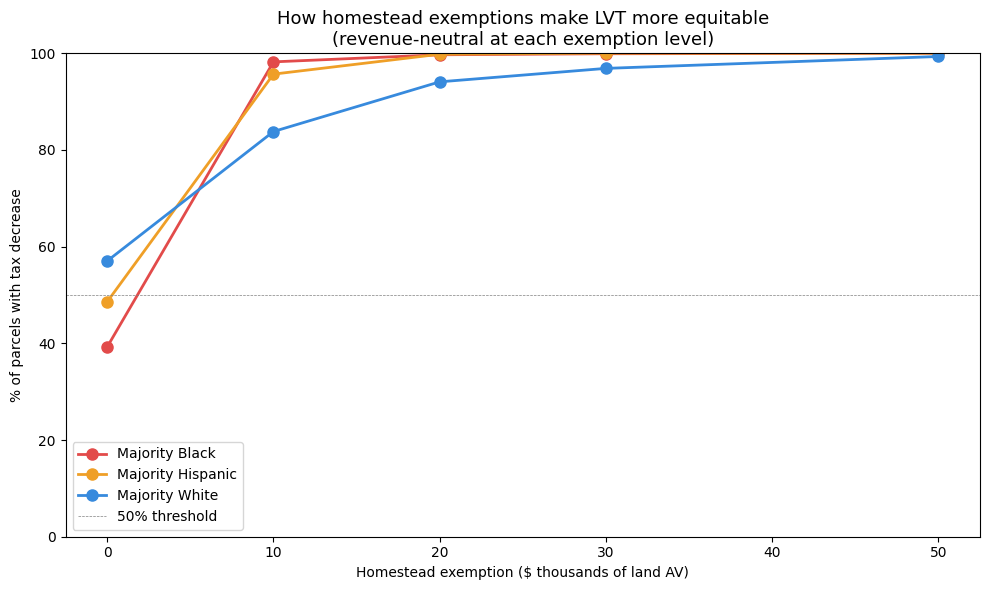

In [12]:
# Plot exemption effects
exempt_df = pd.DataFrame(exemption_results)

fig, ax = plt.subplots(figsize=(10, 6))
for group, color in colors_group.items():
    ax.plot(exempt_df["exemption"] / 1000, exempt_df[group], 'o-',
            color=color, label=group, linewidth=2, markersize=8)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.5, label="50% threshold")
ax.set_xlabel("Homestead exemption ($ thousands of land AV)")
ax.set_ylabel("% of parcels with tax decrease")
ax.set_title("How homestead exemptions make LVT more equitable\n"
             "(revenue-neutral at each exemption level)", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/homestead_exemption.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 4: Side-by-side maps — k=2 clusters vs redlining legacy

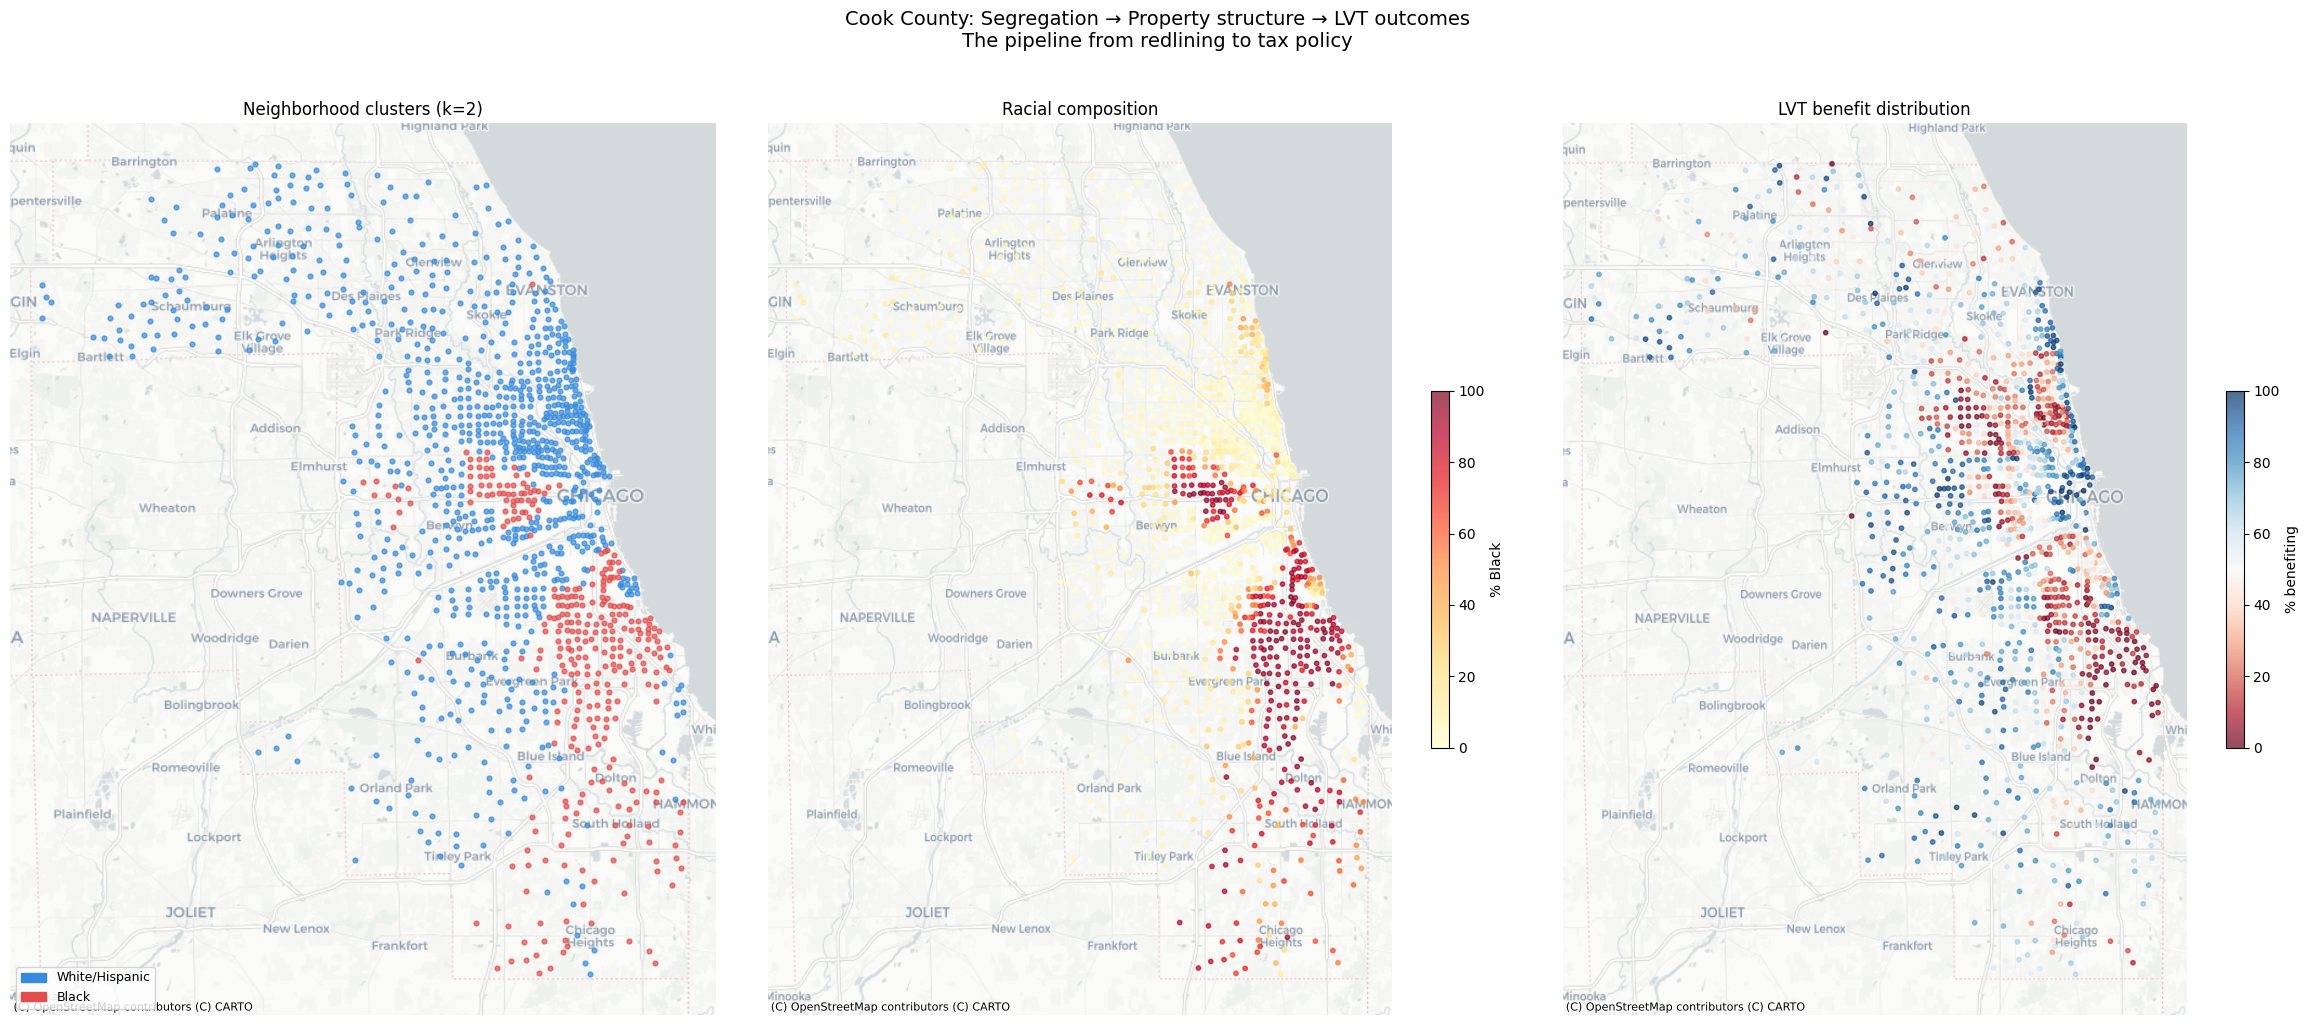

In [13]:
# Side by side: k=2 clusters | LVT impact | racial composition
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Get LVT data for mapping
lvt_tract = res_lvt.groupby("census_tract_geoid").agg(
    pct_benefit=("lvt_benefits", "mean"),
    pct_black=("pct_black", "first"),
    lat=("lat", "median"), lon=("lon", "median"),
).reset_index()
lvt_tract["pct_benefit"] *= 100
lvt_tract = lvt_tract.dropna(subset=["lat", "lon"])
lvt_tract = lvt_tract[(lvt_tract["lat"] > 41.4) & (lvt_tract["lat"] < 42.2) &
                       (lvt_tract["lon"] > -88.3) & (lvt_tract["lon"] < -87.4)]

geom_lvt = [Point(xy) for xy in zip(lvt_tract["lon"], lvt_tract["lat"])]
gdf_lvt = gpd.GeoDataFrame(lvt_tract, geometry=geom_lvt, crs="EPSG:4326").to_crs(epsg=3857)

# Map 1: k=2 clusters
ax = axes[0]
for c in [0, 1]:
    sub = gdf[gdf["cluster"] == c]
    sub.plot(ax=ax, markersize=12, color=colors[c], alpha=0.7)
try: cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass
ax.set_title("Neighborhood clusters (k=2)", fontsize=12)
blue_patch = mpatches.Patch(color="#378ADD", label="White/Hispanic")
red_patch = mpatches.Patch(color="#E24B4A", label="Black")
ax.legend(handles=[blue_patch, red_patch], loc="lower left", fontsize=9)
ax.set_axis_off()

# Map 2: % Black
ax = axes[1]
sc = ax.scatter(gdf_lvt.geometry.x, gdf_lvt.geometry.y,
                c=gdf_lvt["pct_black"], cmap="YlOrRd", vmin=0, vmax=100, s=10, alpha=0.7)
try: cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass
plt.colorbar(sc, ax=ax, shrink=0.4, label="% Black")
ax.set_title("Racial composition", fontsize=12)
ax.set_axis_off()

# Map 3: LVT benefit
ax = axes[2]
sc = ax.scatter(gdf_lvt.geometry.x, gdf_lvt.geometry.y,
                c=gdf_lvt["pct_benefit"], cmap="RdBu", vmin=0, vmax=100, s=10, alpha=0.7)
try: cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass
plt.colorbar(sc, ax=ax, shrink=0.4, label="% benefiting")
ax.set_title("LVT benefit distribution", fontsize=12)
ax.set_axis_off()

plt.suptitle("Cook County: Segregation → Property structure → LVT outcomes\n"
             "The pipeline from redlining to tax policy", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/triple_map.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Part 5: Summary

In [14]:
print("=" * 60)
print("REFINED ANALYSIS SUMMARY")
print("=" * 60)
print("""
KEY FINDING (REFINED):

LVT's benefits depend on property structure, which is itself
shaped by racial history. The policy works as intended —
incentivizing investment, penalizing speculation — but the
TRANSITION costs fall on communities least able to bear them
without complementary support.

The k=2 clustering reveals that the fundamental axis of
variation in Cook County's property tax landscape is racial
segregation. The GMM discovers this from property data alone,
without being told about race.

POLICY IMPLICATIONS:

1. LVT should be PHASED IN (20% per year over 5 years)
   to give households time to invest in improvements.

2. A HOMESTEAD EXEMPTION shielding the first $X of land value
   directly protects low-income homeowners in redlined areas.

3. RENOVATION ASSISTANCE (low-interest loans, grants) should
   accompany LVT to help build improvement value in
   neighborhoods where redlining destroyed it.

4. The combination of LVT + exemptions + investment is more
   equitable than either the current system OR pure LVT alone.

This is not a rejection of LVT — it's a prescription for
how to implement it equitably.
""")

REFINED ANALYSIS SUMMARY

KEY FINDING (REFINED):

LVT's benefits depend on property structure, which is itself
shaped by racial history. The policy works as intended —
incentivizing investment, penalizing speculation — but the
TRANSITION costs fall on communities least able to bear them
without complementary support.

The k=2 clustering reveals that the fundamental axis of
variation in Cook County's property tax landscape is racial
segregation. The GMM discovers this from property data alone,
without being told about race.

POLICY IMPLICATIONS:

1. LVT should be PHASED IN (20% per year over 5 years)
   to give households time to invest in improvements.

2. A HOMESTEAD EXEMPTION shielding the first $X of land value
   directly protects low-income homeowners in redlined areas.

3. RENOVATION ASSISTANCE (low-interest loans, grants) should
   accompany LVT to help build improvement value in
   neighborhoods where redlining destroyed it.

4. The combination of LVT + exemptions + investment 